# Automobile Price Analysis & Prediction

## 1. Data Loading & Understanding

In [2]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Read the online file by the URL provides above, and assign it to variable "df"
file_url = "cars_data.csv"

df = pd.read_csv(
    file_url,
    na_values="?",
    header=None
)

In [4]:
# show the first 5 rows using dataframe.head() method
print("The first 5 rows of the dataframe") 
df.head()

The first 5 rows of the dataframe


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [5]:
# create headers list
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]
print("headers\n", headers)

headers
 ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


In [6]:
# We replace headers and recheck our dataframe:
df.columns = headers
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250.0
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710.0
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,18920.0
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875.0
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160.0,5500.0,16,22,NaN


In [7]:
# Check number of rows and columns
df.shape

(205, 26)

In [8]:
# Check column names
list(df.columns)

['symboling',
 'normalized-losses',
 'make',
 'fuel-type',
 'aspiration',
 'num-doors',
 'body-style',
 'drive-wheels',
 'engine-location',
 'wheel-base',
 'length',
 'width',
 'height',
 'curb-weight',
 'engine-type',
 'num-cylinders',
 'engine-size',
 'fuel-system',
 'bore',
 'stroke',
 'compression-ratio',
 'horsepower',
 'peak-rpm',
 'city-mpg',
 'highway-mpg',
 'price']

In [9]:
# Check data types
df.dtypes

symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-doors             object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-cylinders         object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

In [10]:
# Get complete dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-doors          203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-cylinders      205 non-null    object 
 16  engine-size        205 non

In [11]:
# Check missing values
df.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-doors             2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-cylinders         0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [12]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Generate statistical summary
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [14]:
# To see both numerical and categorical columns
df.describe(include="all")

,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205,205,205,203,205,205,205,205.000000,...,205.000000,205,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
unique,NaN,NaN,22,2,2,2,5,3,2,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,185,168,114,96,120,202,NaN,...,NaN,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.834146,122.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000


In [15]:
# # To see numerical columns
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [16]:
# Check unique values
df["body-style"].unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

In [17]:
# Check unique values
df["drive-wheels"].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [18]:
# Check unique values
df["fuel-type"].unique()

array(['gas', 'diesel'], dtype=object)

In [19]:
# Count values in a categorical column
# This tells us how many cars use each fuel type.
df["fuel-type"].value_counts()

fuel-type
gas       185
diesel     20
Name: count, dtype: int64

In [20]:
df["body-style"].value_counts()

body-style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

In [21]:
df["drive-wheels"].value_counts()

drive-wheels
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64

## Data Loading & Understanding Summary

- The Automobile dataset contains **205 records and 26 features**.
- The dataset includes both **numerical and categorical variables** related to automobile specifications and pricing.
- The main variables include vehicle make, fuel type, body style, drive wheels, engine size, horsepower, mileage, and price.
- The dataset contains **missing values** in columns such as `normalized_losses`, `num_doors`, `bore`, `stroke`, `horsepower`, `peak_rpm`, and `price`.
- No duplicate records were identified during the initial inspection.
- The dataset contains **185 gas vehicles and 20 diesel vehicles**.
- The `price` column contains **201 non-null records** and will be an important variable for further analysis.
- Initial statistical analysis shows that automobile prices range from **5,118 to 45,400**.
- The dataset is not yet ready for analysis because missing values and some data-type issues need to be addressed.
- Therefore, the next step is **Data Cleaning**.

## 2. Data Cleaning

In [22]:
# Check missing values
missing = df.isnull().sum()
print("Missing Values:")
print(missing[missing > 0])

Missing Values:
normalized-losses    41
num-doors             2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


In [23]:
# Convert numerical columns to numeric
numeric_columns = [
    "symboling",
    "normalized-losses",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-size",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# Fill numerical missing values with median
numeric_missing_columns = [
    "normalized-losses",
    "bore",
    "stroke",
    "horsepower",
    "peak-rpm"
]

for col in numeric_missing_columns:
    df[col] = df[col].fillna(df[col].median())


# Fill categorical missing value with mode
df["num-doors"] = df["num-doors"].fillna(
    df["num-doors"].mode()[0]
)


# Convert number of doors
df["num-doors"] = df["num-doors"].map({
    "two": 2,
    "four": 4
})


# Convert number of cylinders
cylinder_mapping = {
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "eight": 8,
    "twelve": 12
}

df["num-cylinders"] = df["num-cylinders"].map(cylinder_mapping)


# Remove rows with missing price
df = df.dropna(subset=["price"])


# Check and remove duplicates
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()


# Final checks
print("\nFinal Shape:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Duplicate rows: 0

Final Shape: (201, 26)

Remaining Missing Values:
symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-doors            0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-cylinders        0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

Data Types:
symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-doors              int64
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length           

## Data Cleaning Summary

- The dataset initially contained 205 automobile records and 26 features.
- Missing values were identified and handled appropriately.
- Numerical missing values were treated using median imputation.
- Categorical missing values were treated using mode imputation.
- Records with missing price values were removed.
- Categorical values such as number of doors and cylinders were converted into   numerical values.
- Duplicate records were checked, and no duplicates were found.
- After cleaning, the dataset contains 201 records and 26 features.
- There are no remaining missing values in the cleaned dataset.
- All columns have been converted to appropriate data types.

## 3. Exploratory Data Analysis (EDA)

Categorical Analysis

In [24]:
df["make"].value_counts()

make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
plymouth          7
audi              6
saab              6
porsche           4
chevrolet         3
alfa-romero       3
jaguar            3
isuzu             2
renault           2
mercury           1
Name: count, dtype: int64

In [25]:
df["fuel-type"].value_counts()

fuel-type
gas       181
diesel     20
Name: count, dtype: int64

In [26]:
df["body-style"].value_counts()

body-style
sedan          94
hatchback      68
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

In [27]:
df["drive-wheels"].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

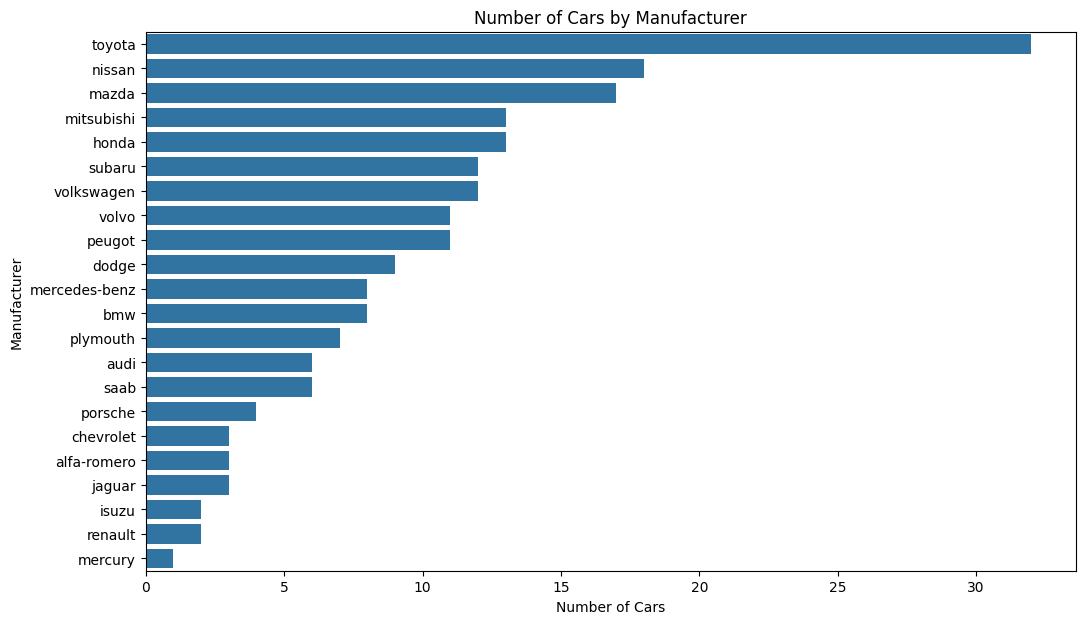

In [28]:
# Manufacturer Distribution
plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    y="make",
    order=df["make"].value_counts().index
)

plt.title("Number of Cars by Manufacturer")
plt.xlabel("Number of Cars")
plt.ylabel("Manufacturer")

plt.show()

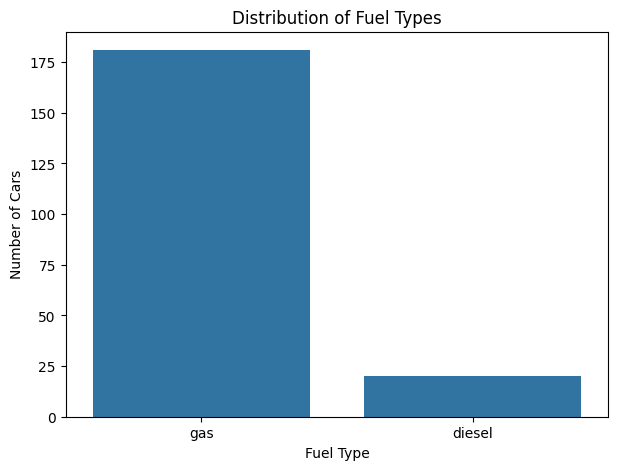

In [29]:
# Fuel Type
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="fuel-type"
)

plt.title("Distribution of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

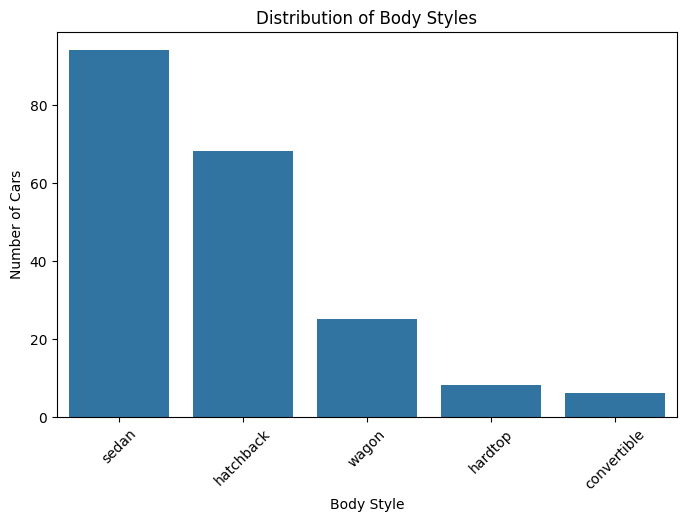

In [30]:
# Body Style
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="body-style",
    order=df["body-style"].value_counts().index
)

plt.title("Distribution of Body Styles")
plt.xlabel("Body Style")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()

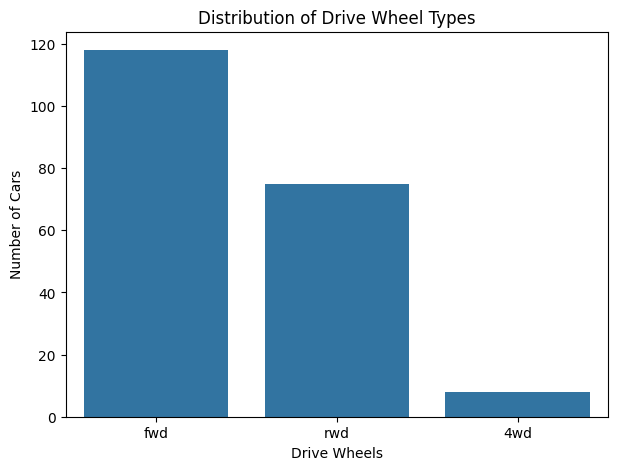

In [31]:
# Drive Wheels
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="drive-wheels",
    order=df["drive-wheels"].value_counts().index
)

plt.title("Distribution of Drive Wheel Types")
plt.xlabel("Drive Wheels")
plt.ylabel("Number of Cars")

plt.show()

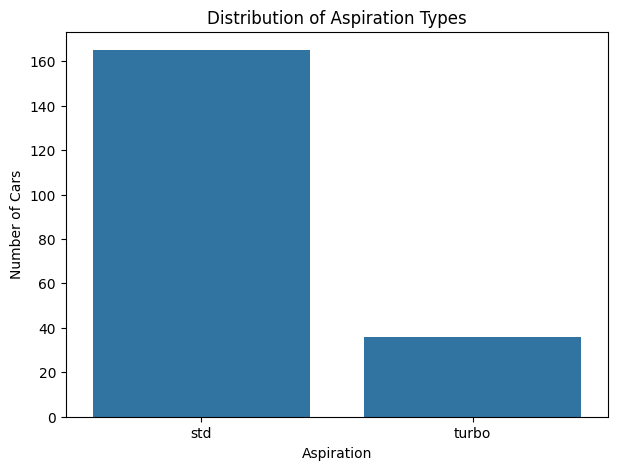

In [32]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="aspiration",
    order=df["aspiration"].value_counts().index
)

plt.title("Distribution of Aspiration Types")
plt.xlabel("Aspiration")
plt.ylabel("Number of Cars")
plt.show()

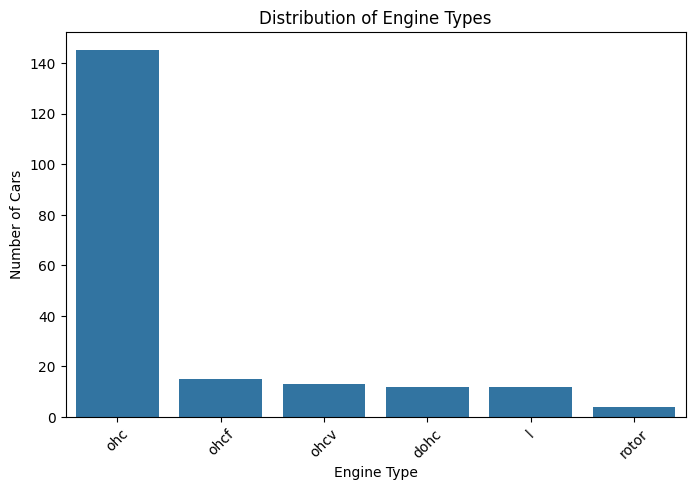

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="engine-type",
    order=df["engine-type"].value_counts().index
)

plt.title("Distribution of Engine Types")
plt.xlabel("Engine Type")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)

plt.show()

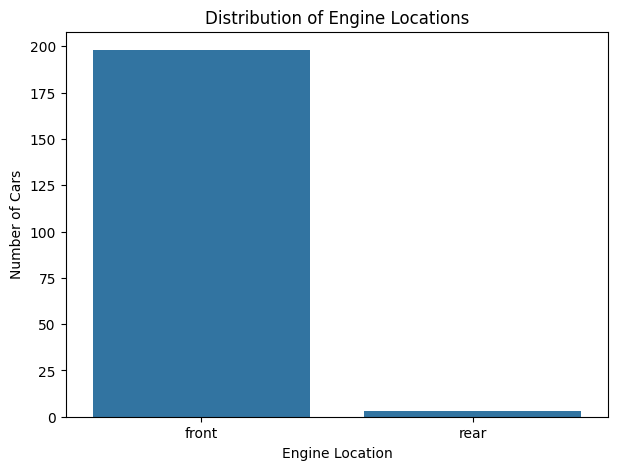

In [34]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="engine-location"
)

plt.title("Distribution of Engine Locations")
plt.xlabel("Engine Location")
plt.ylabel("Number of Cars")

plt.show()

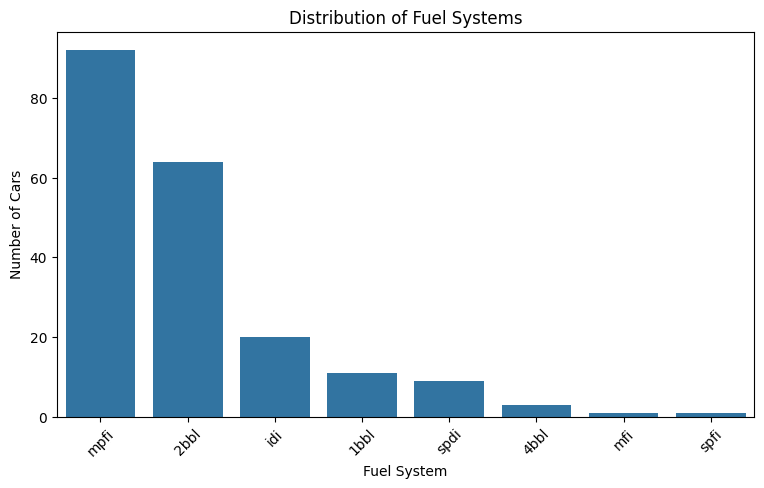

In [35]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="fuel-system",
    order=df["fuel-system"].value_counts().index
)

plt.title("Distribution of Fuel Systems")
plt.xlabel("Fuel System")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)

plt.show()

Numerical Analysis

In [36]:
# Descriptive Statistics
numerical_columns = [
    "price",
    "horsepower",
    "engine-size",
    "curb-weight",
    "wheel-base",
    "length",
    "width",
    "height",
    "city-mpg",
    "highway-mpg",
    "compression-ratio"
]

df[numerical_columns].describe()

,price,horsepower,engine-size,curb-weight,wheel-base,length,width,height,city-mpg,highway-mpg,compression-ratio
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,13207.129353,103.313433,126.875622,2555.666667,98.797015,174.200995,65.889055,53.766667,25.179104,30.686567,10.164279
std,7947.066342,37.374942,41.546834,517.296727,6.066366,12.322175,2.101471,2.447822,6.423220,6.815150,4.004965
min,5118.000000,48.000000,61.000000,1488.000000,86.600000,141.100000,60.300000,47.800000,13.000000,16.000000,7.000000
25%,7775.000000,70.000000,98.000000,2169.000000,94.500000,166.800000,64.100000,52.000000,19.000000,25.000000,8.600000
50%,10295.000000,95.000000,120.000000,2414.000000,97.000000,173.200000,65.500000,54.100000,24.000000,30.000000,9.000000
75%,16500.000000,116.000000,141.000000,2926.000000,102.400000,183.500000,66.600000,55.500000,30.000000,34.000000,9.400000
max,45400.000000,262.000000,326.000000,4066.000000,120.900000,208.100000,72.000000,59.800000,49.000000,54.000000,23.000000


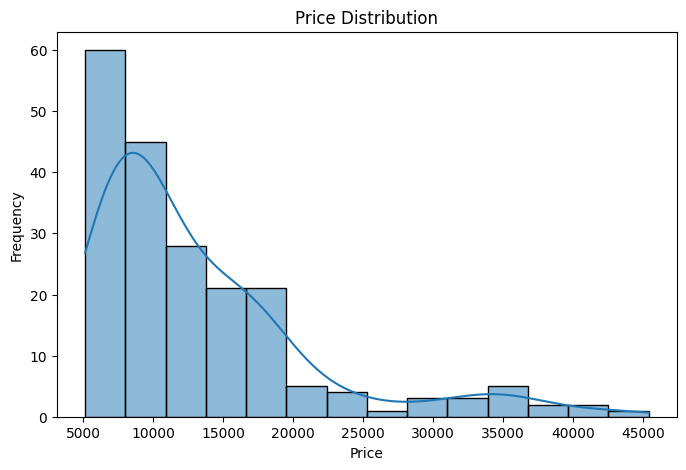

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

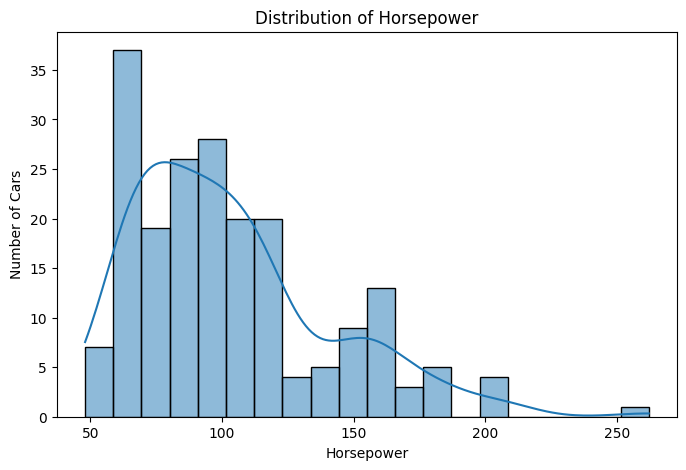

In [38]:
# Horsepower Distribution
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="horsepower", bins=20, kde=True)

plt.title("Distribution of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Number of Cars")

plt.show()

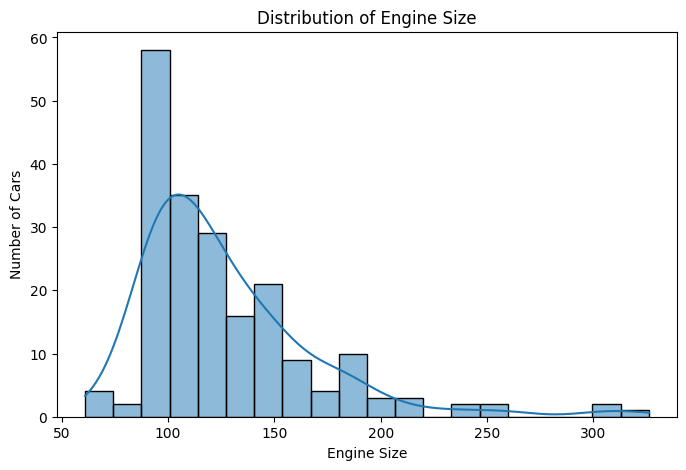

In [39]:
# Engine Size Distribution
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="engine-size", bins=20, kde=True)

plt.title("Distribution of Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Number of Cars")

plt.show()

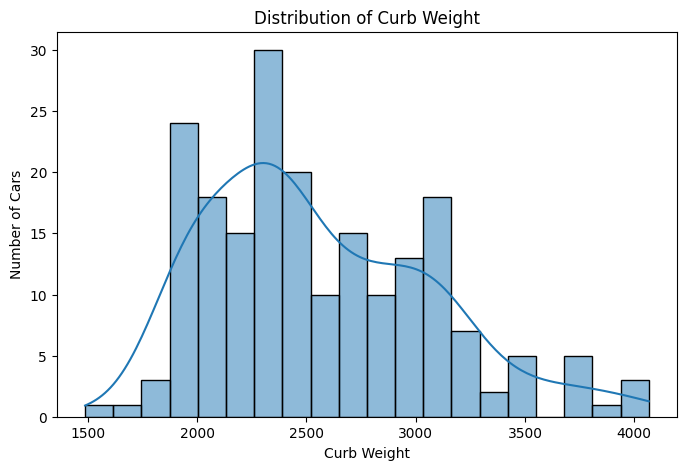

In [40]:
# Curb Weight Distribution
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="curb-weight", bins=20, kde=True)

plt.title("Distribution of Curb Weight")
plt.xlabel("Curb Weight")
plt.ylabel("Number of Cars")

plt.show()

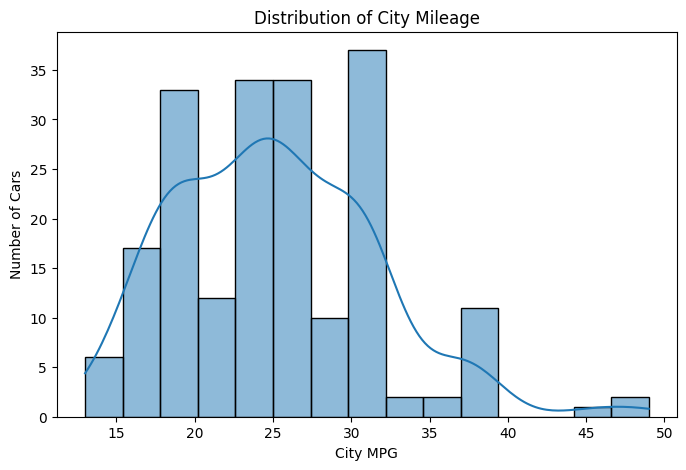

In [41]:
# City MPG Distribution
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="city-mpg", bins=15, kde=True)

plt.title("Distribution of City Mileage")
plt.xlabel("City MPG")
plt.ylabel("Number of Cars")

plt.show()

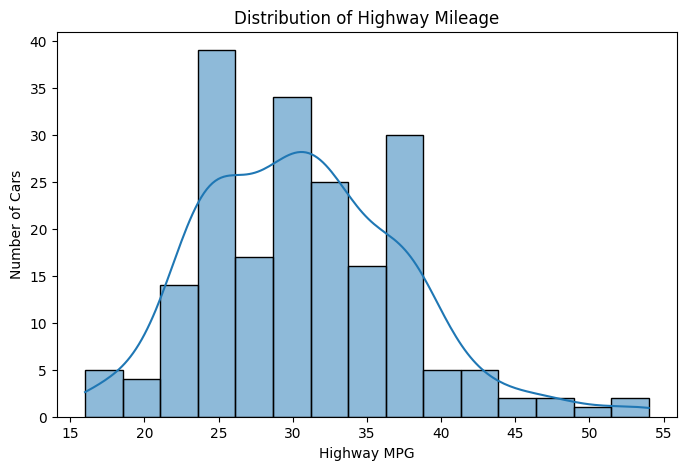

In [42]:
# Highway MPG Distribution
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="highway-mpg", bins=15, kde=True)

plt.title("Distribution of Highway Mileage")
plt.xlabel("Highway MPG")
plt.ylabel("Number of Cars")

plt.show()

Bivariate Analysis: Price Relationships

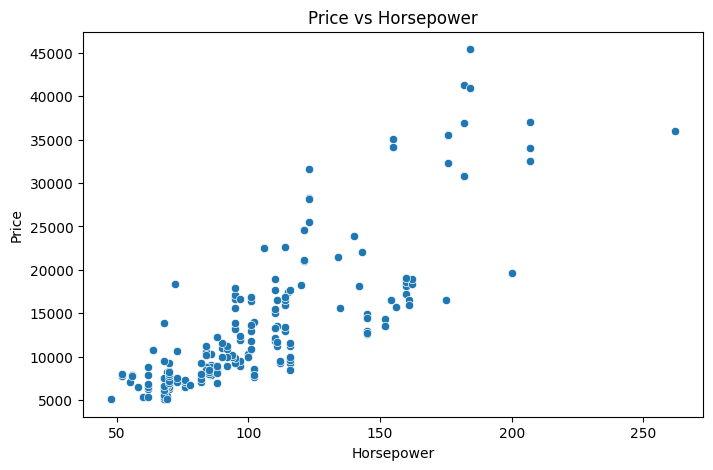

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="horsepower",
    y="price"
)

plt.title("Price vs Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Price")

plt.savefig("price_vs_horsepower.png", dpi=300, bbox_inches="tight")
plt.show()

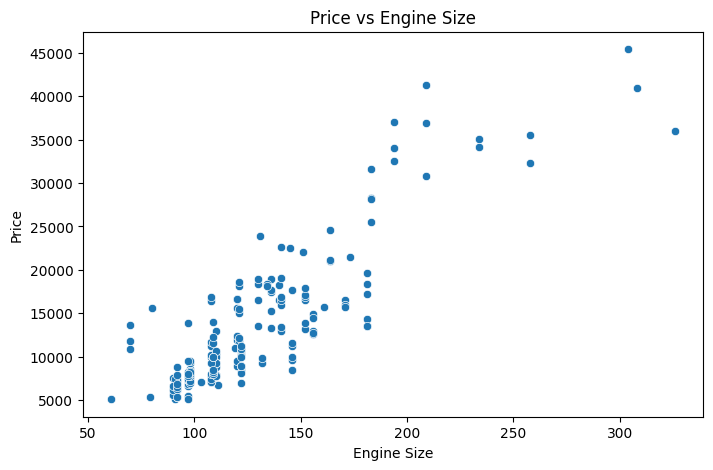

In [44]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="engine-size",
    y="price"
)

plt.title("Price vs Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Price")

plt.savefig("price_vs_engine_size.png", dpi=300, bbox_inches="tight")
plt.show()

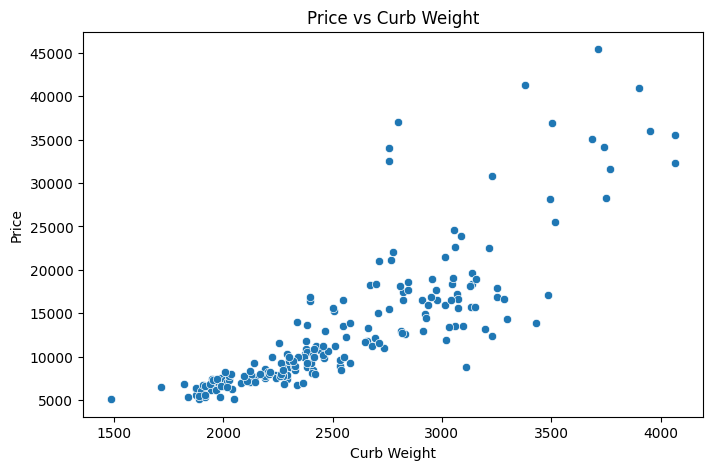

In [45]:
# Price vs Curb Weight
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="curb-weight",
    y="price"
)

plt.title("Price vs Curb Weight")
plt.xlabel("Curb Weight")
plt.ylabel("Price")

plt.show()

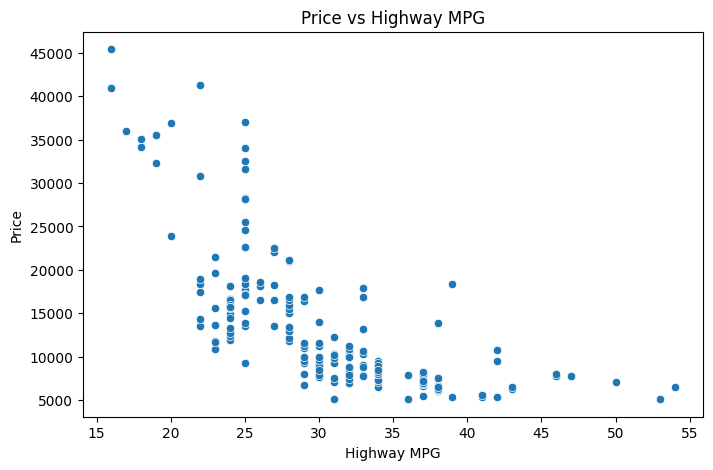

In [46]:
# Price vs Highway MPG
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="highway-mpg",
    y="price"
)

plt.title("Price vs Highway MPG")
plt.xlabel("Highway MPG")
plt.ylabel("Price")

plt.show()

In [47]:
correlation_columns = [
    "price",
    "horsepower",
    "engine-size",
    "curb-weight",
    "highway-mpg"
]

df[correlation_columns].corr()["price"].sort_values(ascending=False)

price          1.000000
engine-size    0.872335
curb-weight    0.834415
horsepower     0.810500
highway-mpg   -0.704692
Name: price, dtype: float64

Price vs Categorical Variables

Price vs Make

In [48]:
# Calculate average price by manufacturer
avg_price_by_make = (
    df.groupby("make")["price"]
      .mean()
      .sort_values(ascending=False)
)

avg_price_by_make

make
jaguar           34600.000000
mercedes-benz    33647.000000
porsche          31400.500000
bmw              26118.750000
volvo            18063.181818
audi             17859.166667
mercury          16503.000000
alfa-romero      15498.333333
peugot           15489.090909
saab             15223.333333
mazda            10652.882353
nissan           10415.666667
volkswagen       10077.500000
toyota            9885.812500
renault           9595.000000
mitsubishi        9239.769231
isuzu             8916.500000
subaru            8541.250000
honda             8184.692308
plymouth          7963.428571
dodge             7875.444444
chevrolet         6007.000000
Name: price, dtype: float64

In [49]:
# Calculate median price
median_price_by_make = (
    df.groupby("make")["price"]
      .median()
      .sort_values(ascending=False)
)

median_price_by_make

make
jaguar           35550.0
porsche          33278.0
mercedes-benz    32892.0
bmw              22835.0
volvo            18420.0
audi             17580.0
peugot           16630.0
mercury          16503.0
alfa-romero      16500.0
saab             15275.0
mazda            10595.0
volkswagen        9737.5
renault           9595.0
toyota            9103.0
isuzu             8916.5
mitsubishi        8499.0
nissan            8124.0
subaru            7894.0
dodge             7609.0
plymouth          7609.0
honda             7295.0
chevrolet         6295.0
Name: price, dtype: float64

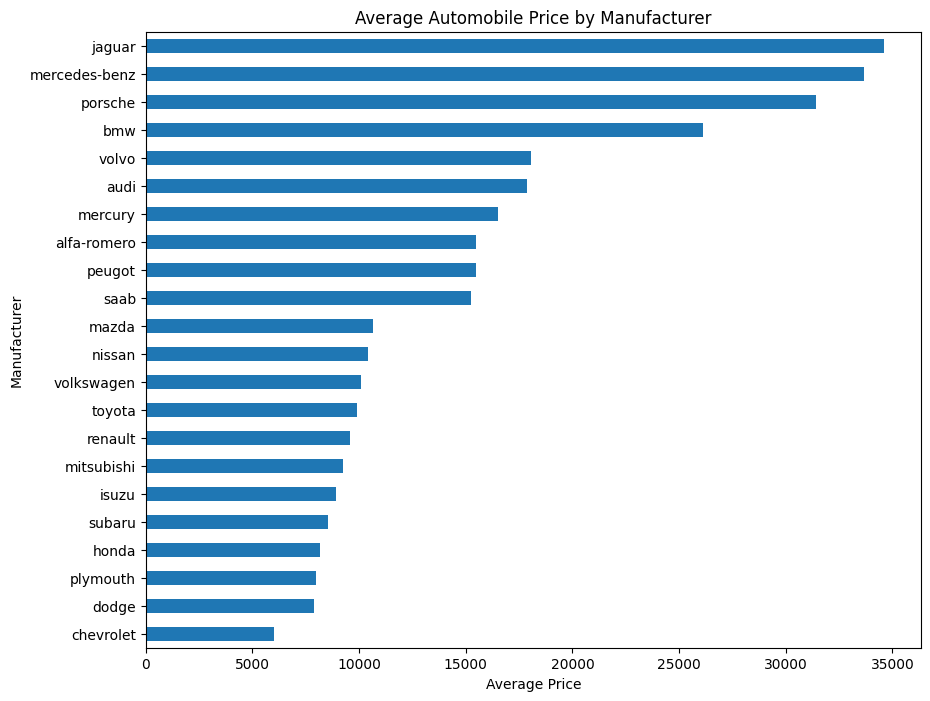

In [50]:
# Visualize Average Price by Make
plt.figure(figsize=(10, 8))

avg_price_by_make.sort_values().plot(kind="barh")

plt.title("Average Automobile Price by Manufacturer")
plt.xlabel("Average Price")
plt.ylabel("Manufacturer")

plt.show()

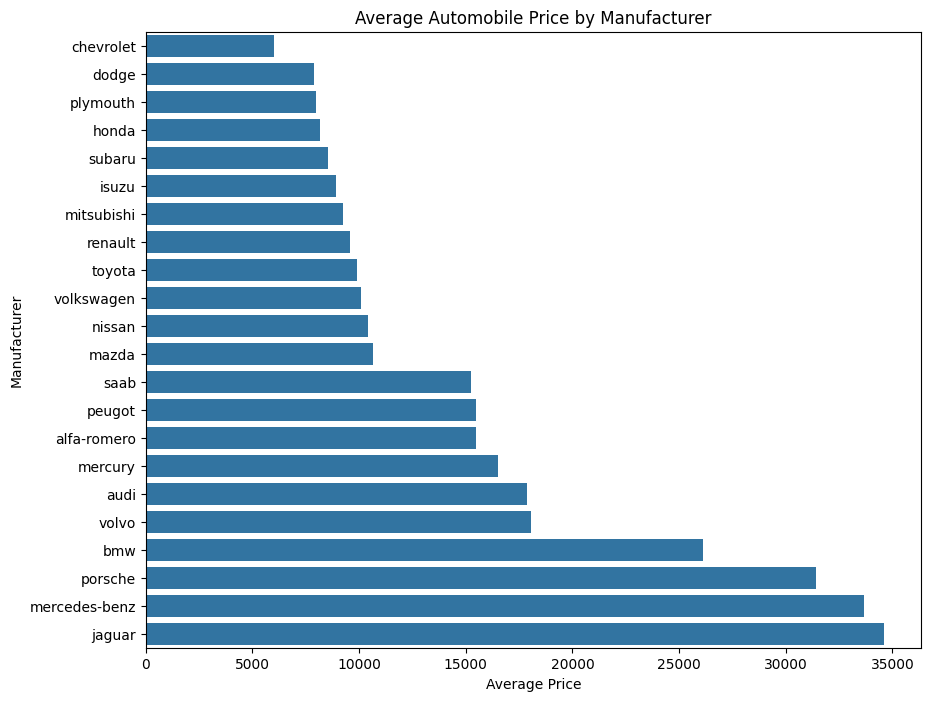

In [51]:
# Better visualization using Seaborn
plt.figure(figsize=(10, 8))

sns.barplot(
    data=df,
    x="price",
    y="make",
    estimator="mean",
    errorbar=None,
    order=df.groupby("make")["price"].mean().sort_values(ascending=True).index
)

plt.title("Average Automobile Price by Manufacturer")
plt.xlabel("Average Price")
plt.ylabel("Manufacturer")

plt.show()

In [52]:
make_summary = (
    df.groupby("make")["price"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

make_summary

,count,mean,median
make,,,
jaguar,3,34600.000000,35550.0
mercedes-benz,8,33647.000000,32892.0
porsche,4,31400.500000,33278.0
bmw,8,26118.750000,22835.0
volvo,11,18063.181818,18420.0
audi,6,17859.166667,17580.0
mercury,1,16503.000000,16503.0
alfa-romero,3,15498.333333,16500.0
peugot,11,15489.090909,16630.0


Price vs Body Style

In [53]:
body_style_summary = (
    df.groupby("body-style")["price"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

body_style_summary

,count,mean,median
body-style,,,
hardtop,8,22208.500000,19687.5
convertible,6,21890.500000,17084.5
sedan,94,14459.755319,11078.5
wagon,25,12371.960000,11694.0
hatchback,68,9957.441176,8672.0


Price vs Fuel Type

In [54]:
fuel_type_summary = (
    df.groupby("fuel-type")["price"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

fuel_type_summary

,count,mean,median
fuel-type,,,
diesel,20,15838.15000,13852.5
gas,181,12916.40884,9989.0


Price vs Drive Wheels

In [55]:
drive_wheels_summary = (
    df.groupby("drive-wheels")["price"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

drive_wheels_summary

,count,mean,median
drive-wheels,,,
rwd,75,19757.613333,16900.0
4wd,8,10241.000000,9005.5
fwd,118,9244.779661,8192.0


Price vs Aspiration

In [56]:
aspiration_summary = (
    df.groupby("aspiration")["price"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

aspiration_summary

,count,mean,median
aspiration,,,
turbo,36,16254.805556,15686.0
std,165,12542.181818,9538.0


## 4. Advanced EDA / Statistical Analysis

4.1 Correlation Analysis

In [57]:
# Select numerical columns
numeric_cols = [
    "symboling",
    "normalized-losses",
    "num-doors",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "num-cylinders",
    "engine-size",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,symboling,normalized-losses,num-doors,wheel-base,length,width,height,curb-weight,num-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
symboling,1.000000,0.457735,-0.672344,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.118016,-0.110581,-0.142547,-0.004387,-0.182196,0.075486,0.279897,-0.035527,0.036233,-0.082391
normalized-losses,0.457735,1.000000,-0.355303,-0.075109,-0.009116,0.061799,-0.371830,0.065393,0.080549,0.073586,-0.052094,0.046024,-0.115967,0.182479,0.245899,-0.193896,-0.150773,0.094366
num-doors,-0.672344,-0.355303,1.000000,0.445245,0.395122,0.227655,0.538383,0.208517,0.002225,0.024094,0.120915,-0.010194,0.169164,-0.102504,-0.232247,-0.027617,-0.045787,0.042435
wheel-base,-0.535987,-0.075109,0.445245,1.000000,0.876024,0.814507,0.590742,0.782097,0.348931,0.572027,0.494065,0.156740,0.250313,0.372156,-0.360946,-0.470606,-0.543304,0.584642
length,-0.365404,-0.009116,0.395122,0.876024,1.000000,0.857170,0.492063,0.880665,0.440348,0.685025,0.609557,0.123016,0.159733,0.578683,-0.285301,-0.665192,-0.698142,0.690628
width,-0.242423,0.061799,0.227655,0.814507,0.857170,1.000000,0.306002,0.866201,0.520118,0.729436,0.544986,0.188605,0.189867,0.614146,-0.245273,-0.633531,-0.680635,0.751265
height,-0.550160,-0.371830,0.538383,0.590742,0.492063,0.306002,1.000000,0.307581,0.007776,0.074694,0.182946,-0.064380,0.259737,-0.086078,-0.310513,-0.049800,-0.104812,0.135486
curb-weight,-0.233118,0.065393,0.208517,0.782097,0.880665,0.866201,0.307581,1.000000,0.604454,0.849072,0.644434,0.166809,0.156433,0.757961,-0.279429,-0.749543,-0.794889,0.834415
num-cylinders,-0.118016,0.080549,0.002225,0.348931,0.440348,0.520118,0.007776,0.604454,1.000000,0.847639,0.205936,0.008480,-0.018138,0.669385,-0.152422,-0.439432,-0.473746,0.708645
engine-size,-0.110581,0.073586,0.024094,0.572027,0.685025,0.729436,0.074694,0.849072,0.847639,1.000000,0.574504,0.203043,0.028889,0.822167,-0.256503,-0.650546,-0.679571,0.872335


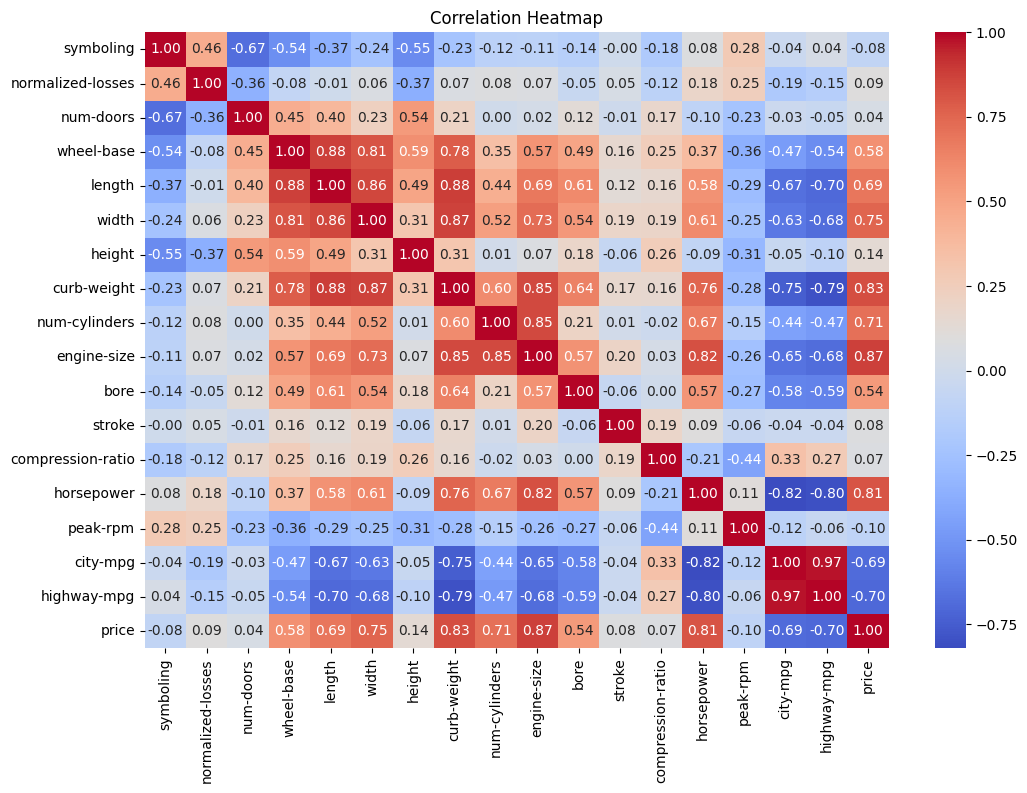

In [58]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

4.2 Outlier Detection

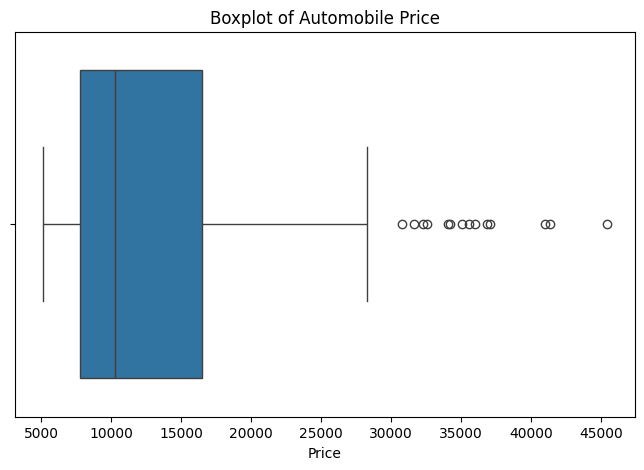

In [59]:
# Boxplot of Price
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["price"])

plt.title("Boxplot of Automobile Price")
plt.xlabel("Price")
plt.show()

In [60]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 7775.0
Q3: 16500.0
IQR: 8725.0
Lower Bound: -5312.5
Upper Bound: 29587.5


In [61]:
price_outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

price_outliers[["make", "body-style", "engine-size", "horsepower", "price"]]

,make,body-style,engine-size,horsepower,price
15,bmw,sedan,209,182.0,30760.0
16,bmw,sedan,209,182.0,41315.0
17,bmw,sedan,209,182.0,36880.0
47,jaguar,sedan,258,176.0,32250.0
48,jaguar,sedan,258,176.0,35550.0
49,jaguar,sedan,326,262.0,36000.0
70,mercedes-benz,sedan,183,123.0,31600.0
71,mercedes-benz,sedan,234,155.0,34184.0
72,mercedes-benz,convertible,234,155.0,35056.0
73,mercedes-benz,sedan,308,184.0,40960.0


In [62]:
outlier_count = len(price_outliers)
total_count = len(df)

outlier_percentage = (outlier_count / total_count) * 100

print("Number of price outliers:", outlier_count)
print("Percentage of price outliers:", outlier_percentage)

Number of price outliers: 14
Percentage of price outliers: 6.965174129353234


In [63]:
# Outliers in Other Important Variables
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Variable:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("Outlier Percentage:", round(len(outliers) / len(df) * 100, 2), "%")
    print("-" * 50)

    return outliers

In [64]:
horsepower_outliers = detect_outliers("horsepower")
engine_size_outliers = detect_outliers("engine-size")
curb_weight_outliers = detect_outliers("curb-weight")

Variable: horsepower
Q1: 70.0
Q3: 116.0
IQR: 46.0
Lower Bound: 1.0
Upper Bound: 185.0
Number of Outliers: 5
Outlier Percentage: 2.49 %
--------------------------------------------------
Variable: engine-size
Q1: 98.0
Q3: 141.0
IQR: 43.0
Lower Bound: 33.5
Upper Bound: 205.5
Number of Outliers: 10
Outlier Percentage: 4.98 %
--------------------------------------------------
Variable: curb-weight
Q1: 2169.0
Q3: 2926.0
IQR: 757.0
Lower Bound: 1033.5
Upper Bound: 4061.5
Number of Outliers: 2
Outlier Percentage: 1.0 %
--------------------------------------------------


4.3 Distribution & Skewness Analysis

In [65]:
# Calculate Price Skewness
price_skewness = df["price"].skew()
print("Price Skewness:", price_skewness)

Price Skewness: 1.8096753390980749


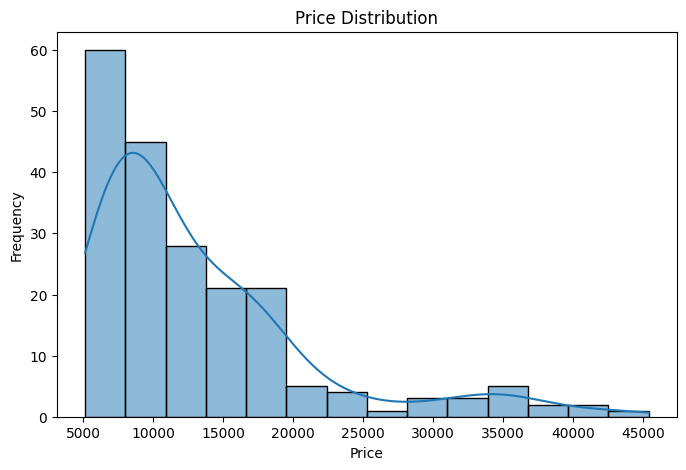

In [66]:
plt.figure(figsize=(8, 5))

sns.histplot(df["price"], kde=True)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [67]:
import numpy as np

df["log_price"] = np.log1p(df["price"])

print("Original Price Skewness:", df["price"].skew())
print("Log Price Skewness:", df["log_price"].skew())

Original Price Skewness: 1.8096753390980749
Log Price Skewness: 0.6787282700171771


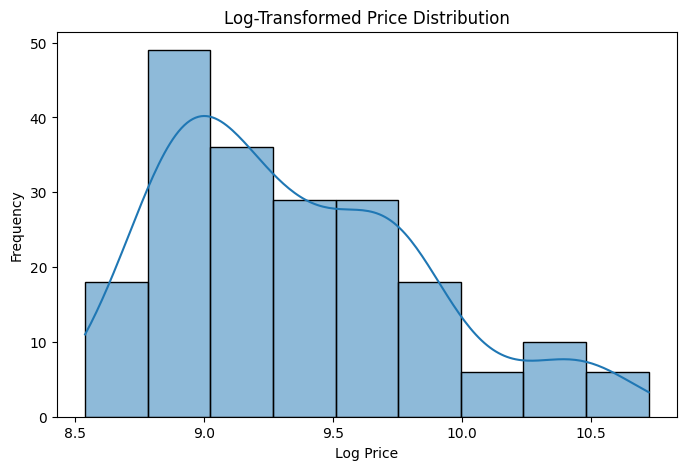

In [68]:
plt.figure(figsize=(8, 5))

sns.histplot(df["log_price"], kde=True)

plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log Price")
plt.ylabel("Frequency")

plt.show()

4.4 Statistical Analysis: Pearson Correlation Significance Testing

In [69]:
from scipy.stats import pearsonr

variables = [
    "engine-size",
    "curb-weight",
    "horsepower",
    "highway-mpg"
]

for var in variables:
    r, p = pearsonr(df[var], df["price"])
    
    print(f"{var}")
    print(f"Correlation (r): {r:.4f}")
    print(f"P-value: {p:.6f}")
    print("-" * 40)

engine-size
Correlation (r): 0.8723
P-value: 0.000000
----------------------------------------
curb-weight
Correlation (r): 0.8344
P-value: 0.000000
----------------------------------------
horsepower
Correlation (r): 0.8105
P-value: 0.000000
----------------------------------------
highway-mpg
Correlation (r): -0.7047
P-value: 0.000000
----------------------------------------


4.5 Advanced Insights

In [70]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

features = [
    "engine-size",
    "curb-weight",
    "horsepower",
    "city-mpg",
    "highway-mpg",
    "width",
    "length",
    "num-cylinders"
]

X = df[features]

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)

vif_data

,Feature,VIF
3,city-mpg,23.878521
4,highway-mpg,23.569887
1,curb-weight,12.615207
0,engine-size,11.593001
2,horsepower,6.369073
6,length,6.211251
5,width,4.866687
7,num-cylinders,4.444104


In [71]:
!pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import sys
print(sys.executable)

C:\Users\Suchita Kunghatkar\AppData\Local\Programs\Python\Python310\python.exe


In [73]:
import sys
!{sys.executable} -m pip install statsmodels

'C:\Users\Suchita' is not recognized as an internal or external command,
operable program or batch file.


In [74]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])

0

In [75]:
import statsmodels

print("statsmodels version:", statsmodels.__version__)

statsmodels version: 0.15.0


In [76]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("VIF imported successfully!")

VIF imported successfully!


## 5. Feature Engineering / Preparation for Modeling

In [77]:
print(df.columns.tolist())

['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price', 'log_price']


In [78]:
# Separate X and y

X = df.drop(columns=["price", "log_price"])
y = df["price"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (201, 25)
y shape: (201,)


In [79]:
# Identify Numerical and Categorical Features

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system']

Numerical Features:
['symboling', 'normalized-losses', 'num-doors', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'num-cylinders', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']


In [80]:
# Encoding & Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [81]:
# Final Train/Test Preparation

from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression pipeline created successfully!")

Linear Regression pipeline created successfully!


## 6 Model Building

Step 6.1 — Train the Linear Regression Model

In [82]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (160, 25)
Testing data shape: (41, 25)


In [83]:
# Train the Linear Regression model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [84]:
# Predict automobile prices on the test data
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE  : 1721.20
RMSE : 2802.64
R²   : 0.9358


In [86]:
# Check actual vs predicted prices

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0        8249.0      8170.867675
1       41315.0     27948.864733
2        6855.0      5956.361921
3        9258.0      7348.882130
4       11850.0     12814.672128
5        5572.0      5681.342722
6       35056.0     36009.499224
7        9988.0      9629.954700
8       15998.0     16743.918089
9       35550.0     32232.972391


In [87]:
comparison["Error"] = comparison["Actual Price"] - comparison["Predicted Price"]

print(comparison.head(10))

   Actual Price  Predicted Price         Error
0        8249.0      8170.867675     78.132325
1       41315.0     27948.864733  13366.135267
2        6855.0      5956.361921    898.638079
3        9258.0      7348.882130   1909.117870
4       11850.0     12814.672128   -964.672128
5        5572.0      5681.342722   -109.342722
6       35056.0     36009.499224   -953.499224
7        9988.0      9629.954700    358.045300
8       15998.0     16743.918089   -745.918089
9       35550.0     32232.972391   3317.027609


Step 6.2 — Random Forest Regression

In [88]:
# Create the Random Forest model
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Create Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


In [89]:
# Train the model
# Train Random Forest model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [90]:
# Generate predictions
# Predict prices on the test data
rf_pred = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [91]:
# Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate Random Forest metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-" * 35)
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
-----------------------------------
MAE  : 1855.90
RMSE : 2885.01
R²   : 0.9320


## 7. Model Interpretation

Step 7.1 — Feature Importance / Coefficient Interpretation.

In [92]:
# Linear Regression — Coefficient Interpretation

# Get feature names after preprocessing
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

# Get Linear Regression coefficients
coefficients = linear_model.named_steps["model"].coef_

# Create a DataFrame
linear_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient for ranking
linear_importance["Absolute_Coefficient"] = (
    linear_importance["Coefficient"].abs()
)

# Sort by absolute coefficient
linear_importance = linear_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Top 15 Linear Regression Features")
print("-" * 45)
print(linear_importance.head(15))

Top 15 Linear Regression Features
---------------------------------------------
                                Feature  Coefficient  Absolute_Coefficient
13             categorical__make_peugot -8157.084632           8157.084632
15            categorical__make_porsche  7849.056472           7849.056472
9       categorical__make_mercedes-benz  5846.887089           5846.887089
2                 categorical__make_bmw  5339.121239           5339.121239
17               categorical__make_saab  4080.868056           4080.868056
42        categorical__fuel-system_1bbl -3821.121472           3821.121472
6               categorical__make_isuzu -3602.502769           3602.502769
14           categorical__make_plymouth -3174.944560           3174.944560
37           categorical__engine-type_l  3174.085294           3174.085294
3           categorical__make_chevrolet -3007.258298           3007.258298
4               categorical__make_dodge -3004.288539           3004.288539
1                cat

In [93]:
# Random Forest — Feature Importance

# Get feature names from the preprocessing step
rf_feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get Random Forest feature importance
rf_importance_values = random_forest_model.named_steps[
    "model"
].feature_importances_

# Create DataFrame
rf_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importance_values
})

# Sort by importance
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Random Forest Features")
print("-" * 45)
print(rf_importance.head(15))

Top 15 Random Forest Features
---------------------------------------------
                         Feature  Importance
57        numerical__curb-weight    0.428835
59        numerical__engine-size    0.288474
63         numerical__horsepower    0.062225
66        numerical__highway-mpg    0.057068
65           numerical__city-mpg    0.038864
55              numerical__width    0.026594
53         numerical__wheel-base    0.015770
58      numerical__num-cylinders    0.012123
54             numerical__length    0.008738
2          categorical__make_bmw    0.008669
64           numerical__peak-rpm    0.007880
51  numerical__normalized-losses    0.007036
56             numerical__height    0.005604
60               numerical__bore    0.004970
62  numerical__compression-ratio    0.003427


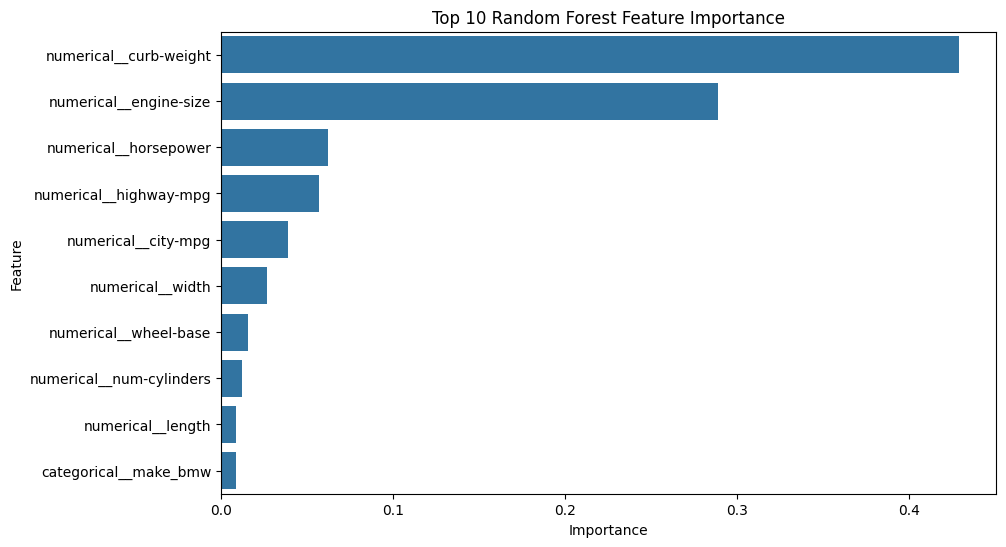

In [94]:
top_features = rf_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()